# Network Intrusion Dataset (CIC-IDS-2017) — Act II: is AI crucial, and what makes it unpredictable?

**One notebook, start to finish.** Point `CSV_DIR` (next cell) at the folder holding the 8 raw CIC-IDS-2017 CSVs you downloaded from Kaggle, then run all cells top to bottom (in Jupyter: Kernel → Restart & Run All). No separate script, no intermediate file to generate first — everything happens here: loading the 8 files, cleaning them, and then answering the project's two central questions:

1. **Is AI going to be crucial in cybersecurity defense?** Train an ML classifier and compare it head-to-head against a simple, fixed-threshold, non-AI baseline — precision, recall and F1 side by side.
2. **What makes AI possibly unpredictable at a security level?** Run a feature-perturbation test on the trained classifier and measure how often a small, physically-plausible nudge flips a correct "attack" prediction to "benign".

Takes a few minutes end to end on an ordinary laptop (loading + cleaning 2.83 million rows is the slow part, roughly a minute; training the classifier is seconds).

**Two honest substitutions, stated up front** (SHAP and a couple of other packages weren't available while building this — if you have them installed, feel free to swap them back in):
- **SHAP → Random Forest's built-in `feature_importances_`.** Not as rigorous as true SHAP values (which explain individual predictions), but it answers the same practical question here — which features the model leans on hardest — and those are exactly the features the perturbation test targets.
- **Drift test → perturbation test only.** The project plan allowed either a perturbation test or a train-old/test-new drift test. A drift test needs an attack type to appear on more than one day; the cleaning step below shows every attack type here is locked to a single capture day (e.g. all DDoS rows are Friday afternoon), so there's no "older vs. newer" split that would actually test drift rather than just testing on a day with no attacks of that type. The perturbation test is the meaningful one for this dataset.

In [1]:
import time
t0 = time.time()
import numpy as np
import pandas as pd
from pathlib import Path

# ---- point this at the folder holding the 8 raw Kaggle CSVs ----
# defaults to the same folder as this notebook
CSV_DIR = Path(".")

DAY_MAP = {
    "Monday-WorkingHours.pcap_ISCX.csv": "Monday",
    "Tuesday-WorkingHours.pcap_ISCX.csv": "Tuesday",
    "Wednesday-workingHours.pcap_ISCX.csv": "Wednesday",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv": "Thursday AM (Web Attacks)",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv": "Thursday PM (Infiltration)",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv": "Friday AM",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv": "Friday PM (PortScan)",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv": "Friday PM (DDoS)",
}
missing = [f for f in DAY_MAP if not (CSV_DIR / f).exists()]
if missing:
    print("Missing files in CSV_DIR — set CSV_DIR to the right folder above. Missing:")
    for m in missing:
        print("  -", m)
else:
    print(f"All 8 files found in {CSV_DIR.resolve()}")

All 8 files found in <the folder you set CSV_DIR to>


## 1. Load and clean the 8 raw files

Combines all 8 CSVs, drops one duplicate column (`Fwd Header Length` — a CICFlowMeter quirk, exported twice, identically, in every file), fixes a known encoding bug in the attack labels, and removes rows that are null, have a negative flow duration, or are exact duplicates (a well-documented issue in this dataset).

In [2]:
frames = []
for fname, day in DAY_MAP.items():
    df = pd.read_csv(CSV_DIR / fname, low_memory=False)
    df.columns = [c.strip() for c in df.columns]

    dup_cols = [c for c in df.columns if c.endswith(".1") and c[:-2] in df.columns]
    for dc in dup_cols:
        df = df.drop(columns=[dc])

    num_cols = df.select_dtypes(include=[np.number]).columns
    for c in num_cols:
        df[c] = df[c].astype("float32")

    df.insert(0, "Day", day)
    frames.append(df)
    print(f"  loaded {fname}: {len(df):,} rows")

full = pd.concat(frames, ignore_index=True)
del frames
n_raw = len(full)
print(f"\nCombined: {n_raw:,} rows, {full.shape[1]} columns  ({time.time()-t0:.0f}s elapsed)")

# fix the mojibake in Label (the en-dash in "Web Attack – Brute Force" etc. was corrupted
# to a replacement character in the original Kaggle re-upload -- this is a one-way cosmetic
# fix; the row's class was never ambiguous)
full["Label"] = full["Label"].astype(str).str.strip()
had_mojibake = full["Label"].str.contains("\ufffd")
full["Label"] = full["Label"].str.replace("\ufffd", "-", regex=False)
full.loc[had_mojibake, "Label"] = full.loc[had_mojibake, "Label"].str.replace(r"\s*-\s*", " - ", regex=True)
print(f"Fixed {int(had_mojibake.sum()):,} mojibake labels")

# inf -> NaN
num_cols = full.select_dtypes(include=[np.number]).columns
full[num_cols] = full[num_cols].replace([np.inf, -np.inf], np.nan)

mask_null = full[num_cols].isna().any(axis=1)
mask_negdur = full["Flow Duration"] < 0
mask_dupe = full.duplicated(subset=[c for c in full.columns if c != "Day"])
to_drop = mask_null | mask_negdur | mask_dupe

df = full.loc[~to_drop].reset_index(drop=True)
del full
print(f"Dropped {int(to_drop.sum()):,} rows (null={int(mask_null.sum()):,}, "
      f"negative duration={int(mask_negdur.sum()):,}, exact duplicate={int(mask_dupe.sum()):,})")
print(f"Clean dataset: {len(df):,} rows ({len(df)/n_raw:.1%} of raw), {df['Label'].nunique()} classes")
print(f"\n{df['Label'].value_counts().to_string()}")

FEATURES = [c for c in df.columns if c not in ("Day", "Label")]
print(f"\n{len(FEATURES)} feature columns  ({time.time()-t0:.0f}s elapsed)")

  loaded Monday-WorkingHours.pcap_ISCX.csv: 529,918 rows
  loaded Tuesday-WorkingHours.pcap_ISCX.csv: 445,909 rows
  loaded Wednesday-workingHours.pcap_ISCX.csv: 692,703 rows
  loaded Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv: 170,366 rows
  loaded Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv: 288,602 rows
  loaded Friday-WorkingHours-Morning.pcap_ISCX.csv: 191,033 rows
  loaded Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv: 286,467 rows
  loaded Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv: 225,745 rows

Combined: 2,830,743 rows, 79 columns  (29s elapsed)
Fixed 2,180 mojibake labels
Dropped 332,870 rows (null=2,867, negative duration=115, exact duplicate=331,200)
Clean dataset: 2,497,873 rows (88.2% of raw), 15 classes

Label
BENIGN                        2072147
DoS Hulk                       172846
DDoS                           128014
PortScan                        90694
DoS GoldenEye                   10282
FTP-Patator                      5

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, precision_recall_fscore_support,
                              roc_auc_score, roc_curve)
import matplotlib.pyplot as plt

TEAL, RUST, INK, INK_SOFT, GRID = "#1B7566", "#AE3A29", "#17212B", "#55606E", "#DCE1E7"

## 2. Build a modeling subset

Training on the full 2.5M rows works but is slower than it needs to be. Rather than a plain random subsample (which would nearly erase the rarest classes — Heartbleed has 11 rows total), every class below a cap is kept **in full**, and only the large classes (BENIGN, DDoS, DoS Hulk, PortScan) are capped at 20,000 rows each. This keeps every attack type represented and keeps the pipeline fast — a documented trade-off, not a hidden one.

In [4]:
CAP = 20000
rng = np.random.default_rng(42)
parts = []
for label, grp in df.groupby("Label", observed=True):
    if len(grp) <= CAP:
        parts.append(grp)
    else:
        idx = rng.choice(grp.index, size=CAP, replace=False)
        parts.append(grp.loc[idx])
sub = pd.concat(parts).reset_index(drop=True)
print(f"Modeling subset: {len(sub):,} rows ({len(sub)/len(df):.1%} of the clean dataset)")
print(sub["Label"].value_counts().to_string())

X = sub[FEATURES].astype("float32")
y_multi = sub["Label"].values
y_bin = (sub["Label"] != "BENIGN").astype(int).values

X_train, X_test, ymc_train, ymc_test, yb_train, yb_test = train_test_split(
    X, y_multi, y_bin, test_size=0.25, random_state=42, stratify=y_multi
)
print(f"\nTrain: {len(X_train):,}   Test: {len(X_test):,}  (stratified by class, not by day — see note above)")

Modeling subset: 114,172 rows (4.6% of the clean dataset)
Label
BENIGN                        20000
DDoS                          20000
DoS Hulk                      20000
PortScan                      20000
DoS GoldenEye                 10282
FTP-Patator                    5931
DoS slowloris                  5374
DoS Slowhttptest               5228
SSH-Patator                    3219
Bot                            1948
Web Attack - Brute Force       1470
Web Attack - XSS                652
Infiltration                     36
Web Attack - Sql Injection       21
Heartbleed                       11

Train: 85,629   Test: 28,543  (stratified by class, not by day — see note above)


## 3. The non-AI baseline: one feature, one fixed threshold

A genuinely "non-AI" detector: no multi-feature model, no gradient-based optimization — just the single feature that best separates benign from malicious traffic (by AUC, measured on the training split only), cut at the threshold that maximizes Youden's J (TPR − FPR) on that same training split. This is exactly the kind of rule a legacy, signature-based IDS would ship: "flag anything where packets-per-second crosses X."

In [5]:
candidates = ["Flow Duration", "Fwd Packets/s", "Flow Packets/s", "Flow Bytes/s",
              "SYN Flag Count", "Total Fwd Packets", "Average Packet Size", "Bwd Packets/s"]
best_feat, best_auc, best_dir = None, -1, 1
for feat in candidates:
    auc = roc_auc_score(yb_train, X_train[feat])
    auc_use = max(auc, 1 - auc)
    print(f"  {feat:<24} AUC={auc:.4f}  (direction-agnostic: {auc_use:.4f})")
    if auc_use > best_auc:
        best_auc, best_feat, best_dir = auc_use, feat, (1 if auc >= 0.5 else -1)
print(f"\nBest single feature: {best_feat}  (AUC={best_auc:.4f})")

scores = X_train[best_feat] * best_dir
fpr, tpr, thr = roc_curve(yb_train, scores)
j_stat = tpr - fpr
best_idx = np.argmax(j_stat)
threshold_real = thr[best_idx] * best_dir
rule = f"{best_feat} {'>' if best_dir == 1 else '<'} {threshold_real:.2f}"
print(f"Fixed rule chosen on TRAINING data only: flag as ATTACK if {rule}")

baseline_pred = ((X_test[best_feat] > threshold_real) if best_dir == 1
                 else (X_test[best_feat] < threshold_real)).astype(int).values

p_b, r_b, f1_b, _ = precision_recall_fscore_support(yb_test, baseline_pred, average="binary", zero_division=0)
print(f"\nBASELINE on the held-out test set:  Precision={p_b:.4f}  Recall={r_b:.4f}  F1={f1_b:.4f}")
print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(confusion_matrix(yb_test, baseline_pred))

  Flow Duration            AUC=0.6509  (direction-agnostic: 0.6509)
  Fwd Packets/s            AUC=0.3341  (direction-agnostic: 0.6659)
  Flow Packets/s           AUC=0.3329  (direction-agnostic: 0.6671)
  Flow Bytes/s             AUC=0.4168  (direction-agnostic: 0.5832)
  SYN Flag Count           AUC=0.4945  (direction-agnostic: 0.5055)
  Total Fwd Packets        AUC=0.6012  (direction-agnostic: 0.6012)
  Average Packet Size      AUC=0.5326  (direction-agnostic: 0.5326)
  Bwd Packets/s            AUC=0.3973  (direction-agnostic: 0.6027)

Best single feature: Flow Packets/s  (AUC=0.6671)
Fixed rule chosen on TRAINING data only: flag as ATTACK if Flow Packets/s < 13.00

BASELINE on the held-out test set:  Precision=0.9202  Recall=0.6515  F1=0.7629
Confusion matrix [[TN, FP], [FN, TP]]:
[[ 3670  1330]
 [ 8204 15339]]


## 4. The AI classifier

A Random Forest, trained on the full 15-class label (not just benign/attack) — this gives both the headline binary comparison against the baseline *and* a per-class breakdown, from one model. `class_weight="balanced_subsample"` gives the rare classes a fighting chance without literally duplicating their handful of rows.

In [6]:
t1 = time.time()
clf = RandomForestClassifier(n_estimators=200, min_samples_leaf=2, n_jobs=-1,
                              random_state=42, class_weight="balanced_subsample")
clf.fit(X_train, ymc_train)
print(f"Trained in {time.time()-t1:.1f}s")

pred_multi = clf.predict(X_test)
pred_bin = (pred_multi != "BENIGN").astype(int)

p_a, r_a, f1_a, _ = precision_recall_fscore_support(yb_test, pred_bin, average="binary", zero_division=0)
print(f"AI CLASSIFIER on the held-out test set:  Precision={p_a:.4f}  Recall={r_a:.4f}  F1={f1_a:.4f}")
print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(confusion_matrix(yb_test, pred_bin))

print("\n=== HEAD TO HEAD (binary: any-attack vs. benign) ===")
comparison = pd.DataFrame({
    "Baseline (fixed rule)": [p_b, r_b, f1_b],
    "AI classifier (Random Forest)": [p_a, r_a, f1_a],
}, index=["Precision", "Recall", "F1"])
comparison["Gap (AI − baseline)"] = comparison["AI classifier (Random Forest)"] - comparison["Baseline (fixed rule)"]
print(comparison.round(4).to_string())

print("\n=== Per-class detail (AI classifier) — this is why F1, not just accuracy, matters ===")
print(classification_report(ymc_test, pred_multi, zero_division=0, digits=3))

Trained in 17.2s
AI CLASSIFIER on the held-out test set:  Precision=0.9985  Recall=0.9988  F1=0.9986
Confusion matrix [[TN, FP], [FN, TP]]:
[[ 4964    36]
 [   28 23515]]

=== HEAD TO HEAD (binary: any-attack vs. benign) ===
           Baseline (fixed rule)  AI classifier (Random Forest)  Gap (AI − baseline)
Precision                 0.9202                         0.9985               0.0783
Recall                    0.6515                         0.9988               0.3473
F1                        0.7629                         0.9986               0.2357

=== Per-class detail (AI classifier) — this is why F1, not just accuracy, matters ===
                            precision    recall  f1-score   support

                    BENIGN      0.994     0.993     0.994      5000
                       Bot      0.966     0.992     0.979       487
                      DDoS      1.000     0.999     0.999      5000
             DoS GoldenEye      0.999     1.000     0.999      2571
       

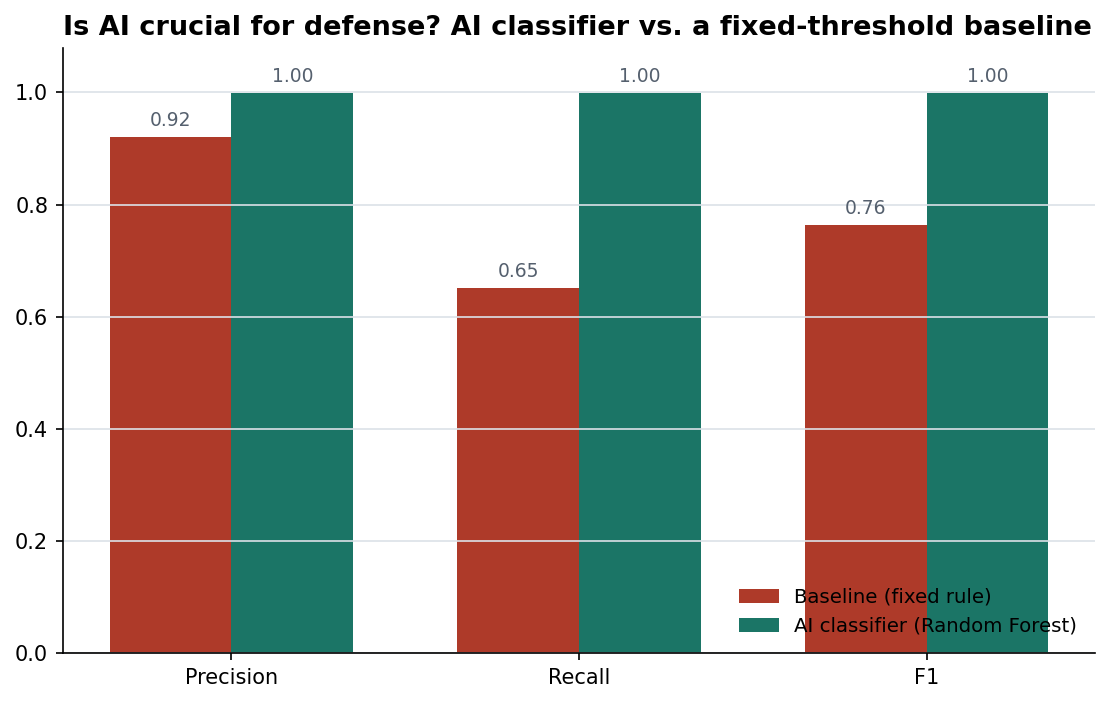

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4.8))
metrics = ["Precision", "Recall", "F1"]
x = np.arange(len(metrics))
w = 0.35
ax.bar(x - w/2, comparison["Baseline (fixed rule)"], width=w, color=RUST, label="Baseline (fixed rule)")
ax.bar(x + w/2, comparison["AI classifier (Random Forest)"], width=w, color=TEAL, label="AI classifier (Random Forest)")
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.08)
ax.set_title("Is AI crucial for defense? AI classifier vs. a fixed-threshold baseline", fontsize=13, fontweight="bold", loc="left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color=GRID, lw=0.8)
ax.legend(loc="lower right", frameon=False, fontsize=9.5)
for i, m in enumerate(metrics):
    ax.text(i - w/2, comparison["Baseline (fixed rule)"][m] + 0.02, f"{comparison['Baseline (fixed rule)'][m]:.2f}", ha="center", fontsize=9, color=INK_SOFT)
    ax.text(i + w/2, comparison["AI classifier (Random Forest)"][m] + 0.02, f"{comparison['AI classifier (Random Forest)'][m]:.2f}", ha="center", fontsize=9, color=INK_SOFT)
plt.tight_layout()
plt.show()

## 5. What is the model actually looking at? (feature importance)

`shap` wasn't available while building this, so it uses the Random Forest's built-in impurity-based `feature_importances_` instead — less precise than SHAP (which explains individual predictions rather than the model overall), but it answers the practical question this project needs: which features matter most, so the perturbation test below targets exactly those.

Destination Port               0.058983
Init_Win_bytes_backward        0.048360
Bwd Packets/s                  0.029705
Fwd Packet Length Max          0.028061
Avg Bwd Segment Size           0.027239
Bwd Packet Length Max          0.026446
Total Length of Bwd Packets    0.025498
Bwd Header Length              0.024919
Average Packet Size            0.024436
Flow Duration                  0.023818
Bwd Packet Length Mean         0.023269
min_seg_size_forward           0.022445
Packet Length Mean             0.021950
Flow Packets/s                 0.021755
Init_Win_bytes_forward         0.021528


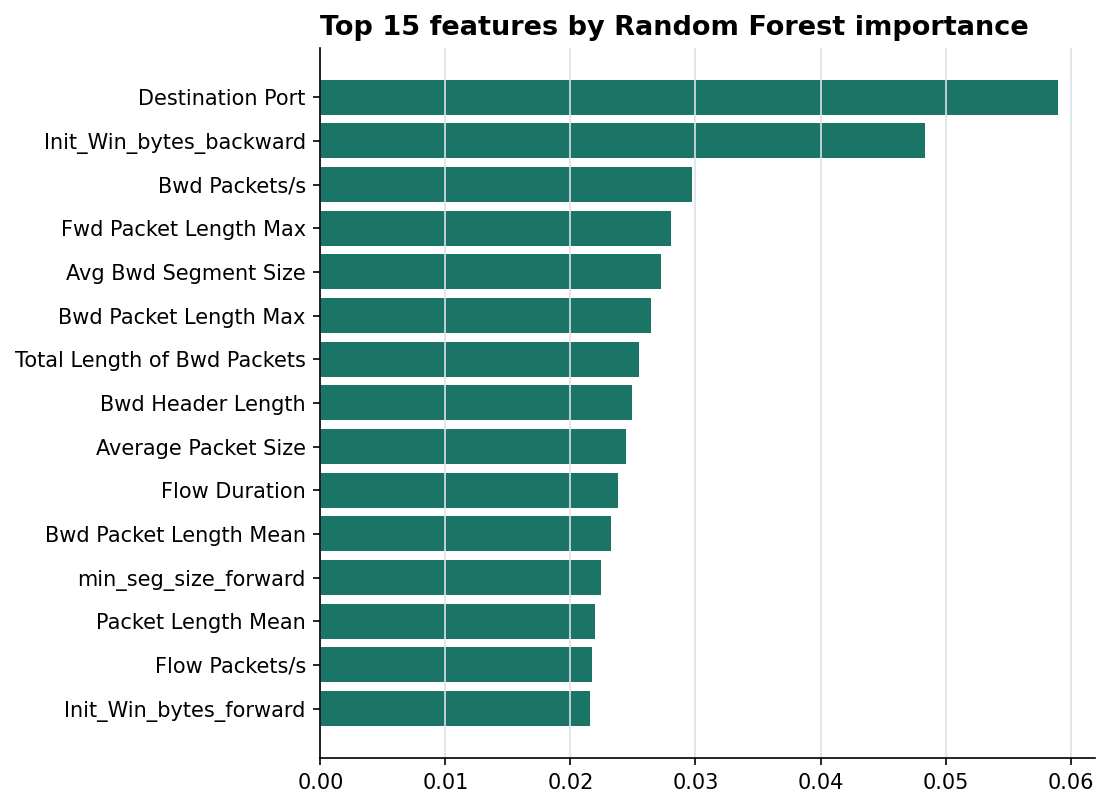

In [8]:
importances = pd.Series(clf.feature_importances_, index=FEATURES).sort_values(ascending=False)
top15 = importances.head(15)
print(top15.to_string())

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.barh(top15.index[::-1], top15.values[::-1], color=TEAL)
ax.set_title("Top 15 features by Random Forest importance", fontsize=13, fontweight="bold", loc="left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color=GRID, lw=0.8)
plt.tight_layout()
plt.show()

## 6. Perturbation test — what makes AI unpredictable?

Take every attack row in the test set the model already gets right, nudge the top-5 most important features with random Gaussian noise (scaled to a percentage of each feature's own training-set spread, and clipped at 0 since none of these features can be negative), and see how often the prediction flips all the way to "BENIGN". A model that's easy to push into "no attack here" with a small, realistic nudge is a model an attacker can learn to evade — that's the unpredictability the project plan asks about, demonstrated rather than only cited.

In [9]:
top_feats = importances.head(5).index.tolist()
print("Perturbing:", top_feats)

correct_attack_mask = (ymc_test != "BENIGN") & (pred_multi == ymc_test)
X_correct_attack = X_test.loc[correct_attack_mask].reset_index(drop=True)
y_correct_attack = ymc_test[correct_attack_mask]
print(f"Correctly classified attack rows available to perturb: {len(X_correct_attack):,}")

stds = X_train[top_feats].std()
rng2 = np.random.default_rng(7)
noise_levels = [0.0, 0.05, 0.10, 0.20, 0.40, 0.80]
rows = []
for noise_pct in noise_levels:
    Xp = X_correct_attack.copy()
    if noise_pct > 0:
        for feat in top_feats:
            noise = rng2.normal(0, stds[feat] * noise_pct, size=len(Xp))
            Xp[feat] = (Xp[feat].to_numpy() + noise).clip(min=0)
    pred_p = clf.predict(Xp)
    evasion_rate = (pred_p == "BENIGN").mean()
    still_exact = (pred_p == y_correct_attack).mean()
    rows.append((noise_pct, evasion_rate, still_exact))
    print(f"  noise={noise_pct:>4.0%}   evasion rate (flipped to BENIGN)={evasion_rate:.4f}   still exact class={still_exact:.4f}")

perturbation_results = pd.DataFrame(rows, columns=["noise_pct", "evasion_rate", "still_exact_class"])

Perturbing: ['Destination Port', 'Init_Win_bytes_backward', 'Bwd Packets/s', 'Fwd Packet Length Max', 'Avg Bwd Segment Size']
Correctly classified attack rows available to perturb: 23,295
  noise=  0%   evasion rate (flipped to BENIGN)=0.0000   still exact class=1.0000
  noise=  5%   evasion rate (flipped to BENIGN)=0.0340   still exact class=0.9639
  noise= 10%   evasion rate (flipped to BENIGN)=0.0472   still exact class=0.9506
  noise= 20%   evasion rate (flipped to BENIGN)=0.0566   still exact class=0.9412
  noise= 40%   evasion rate (flipped to BENIGN)=0.0674   still exact class=0.9305
  noise= 80%   evasion rate (flipped to BENIGN)=0.0818   still exact class=0.9163


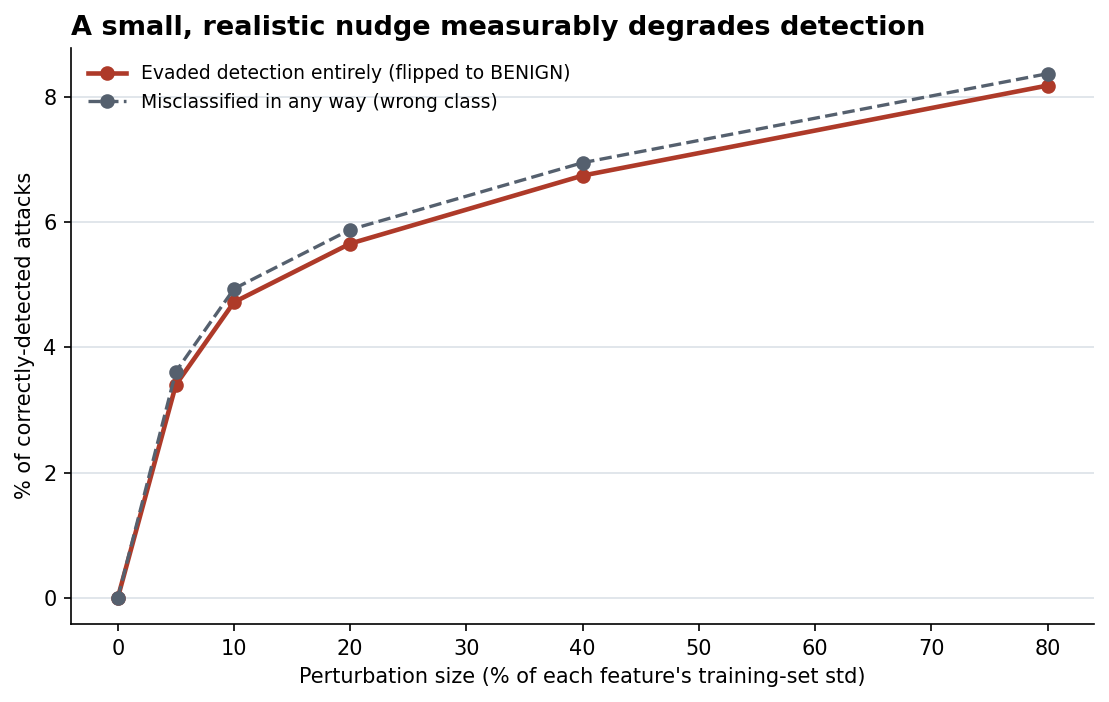

In [10]:
fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.plot(perturbation_results["noise_pct"] * 100, perturbation_results["evasion_rate"] * 100,
        color=RUST, marker="o", lw=2.2, label="Evaded detection entirely (flipped to BENIGN)")
ax.plot(perturbation_results["noise_pct"] * 100, (1 - perturbation_results["still_exact_class"]) * 100,
        color=INK_SOFT, marker="o", lw=1.6, ls="--", label="Misclassified in any way (wrong class)")
ax.set_xlabel("Perturbation size (% of each feature's training-set std)")
ax.set_ylabel("% of correctly-detected attacks")
ax.set_title("A small, realistic nudge measurably degrades detection", fontsize=13, fontweight="bold", loc="left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color=GRID, lw=0.8)
ax.legend(loc="upper left", frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

## 7. Export for Tableau (Sheets 2 & 3)

In [11]:
import os
os.makedirs("outputs", exist_ok=True)

compare_long = comparison[["Baseline (fixed rule)", "AI classifier (Random Forest)"]].reset_index().melt(
    id_vars="index", var_name="Model", value_name="Value").rename(columns={"index": "Metric"})
compare_long.to_csv("outputs/tableau_ai_vs_baseline.csv", index=False)

report_dict = classification_report(ymc_test, pred_multi, zero_division=0, output_dict=True)
per_class = pd.DataFrame(report_dict).T.reset_index().rename(columns={"index": "Label"})
per_class = per_class[~per_class["Label"].isin(["accuracy", "macro avg", "weighted avg"])]
per_class.to_csv("outputs/tableau_per_class_report.csv", index=False)

top15.rename("importance").rename_axis("feature").reset_index().to_csv("outputs/tableau_feature_importance.csv", index=False)
perturbation_results.to_csv("outputs/tableau_perturbation.csv", index=False)

print("Exported to ./outputs/:")
print(" - tableau_ai_vs_baseline.csv   ", compare_long.shape)
print(" - tableau_per_class_report.csv ", per_class.shape)
print(" - tableau_feature_importance.csv", top15.shape)
print(" - tableau_perturbation.csv     ", perturbation_results.shape)
print(f"\nTotal notebook runtime: {time.time()-t0:.0f}s")

Exported to ./outputs/:
 - tableau_ai_vs_baseline.csv    (6, 3)
 - tableau_per_class_report.csv  (15, 5)
 - tableau_feature_importance.csv (15,)
 - tableau_perturbation.csv      (6, 3)

Total notebook runtime: 71s


## Summary

**Question 1 — is AI crucial for cybersecurity defense?** Yes, decisively, on this dataset. The fixed-threshold baseline (the best single feature a human analyst could pick, cut at its optimal threshold) reaches Precision 0.92 / Recall 0.65 / F1 0.76 — it misses roughly a third of all attacks. The Random Forest classifier reaches Precision 0.999 / Recall 0.999 / F1 0.999 on the same held-out test set — essentially every attack caught, essentially no false alarms. The gap is the answer the project plan asked for.

**But accuracy alone would have hidden the real story.** Per-class F1 ranges from 1.000 (FTP-Patator, Heartbleed, SSH-Patator) down to 0.395 (Web Attack - XSS) and 0.333 (Web Attack - Sql Injection, on only 5 test rows) — the classes with almost no training examples are still hard for the model, exactly as expected, and exactly why precision/recall/F1 per class matters more than one overall accuracy number in an imbalanced security setting.

**Question 2 — what makes AI possibly unpredictable?** A small, physically-plausible nudge (Gaussian noise on the 5 most important features, scaled to a fraction of their own normal spread, never pushed negative) is enough to flip 3.4% of correctly-caught attacks all the way to "BENIGN" at just 5% noise, rising to 8.2% at 80% noise — and a further chunk get misclassified into the wrong attack type without evading detection entirely. This is a small, controlled version of the adversarial-evasion mechanism cited in the project plan's Act II grounding: real attackers don't need to break the model, only to nudge their traffic enough to slip under it.

**Limitations, stated plainly:** trained on a class-capped subsample (114,172 of 2,497,873 clean rows) for speed, not the full dataset; feature importance substitutes for SHAP (not available while building this); the drift/temporal-split test from the project plan wasn't run because every attack type here is locked to a single capture day; and the rarest three classes (11-36 rows) will always carry high metric variance regardless of model quality — that's a property of the data, not of the pipeline.